<a href="https://colab.research.google.com/github/Taryn-Cail/Predicting-Dementia-Diagnosis-Using-Lifestyle-and-Health-Factors/blob/main/Final_Copy_of_CS4403_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Dementia Diagnosis Using Lifestyle and Health Factors

CS4403 Project Data Cleaning and Preprocessing
Taryn Cail - 3756155



background and context??

# Imports

In [ ]:
# ==============================
# Standard Libraries
# ==============================
import time
from collections import defaultdict

# ==============================
# Data Handling
# ==============================
import pandas as pd
import numpy as np

# ==============================
# Visualization
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# Preprocessing
# ==============================
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ==============================
# Metrics
# ==============================
from sklearn.metrics import (
    accuracy_score, recall_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, classification_report, roc_curve, auc
)
from sklearn.inspection import permutation_importance

# ==============================
# Models
# ==============================
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
import xgboost as xgb
import shap

# ==============================
# Neural Network (TensorFlow / Keras)
# ==============================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# ==============================
# Install packages if not already installed
# ==============================
!pip install scikit-learn xgboost lightgbm shap matplotlib seaborn tensorflow

# Data Dictionary

Data Dictionary provided by Rabie El Kharoua who created the dataset on Kaggle.
https://www.kaggle.com/datasets/rabieelkharoua/alzheimers-disease-dataset

This dataset contains extensive health information for 2,149 patients, each uniquely identified with IDs ranging from 4751 to 6900. The dataset includes demographic details, lifestyle factors, medical history, clinical measurements, cognitive and functional assessments, symptoms, and a diagnosis of Alzheimer's Disease. The data is ideal for researchers and data scientists looking to explore factors associated with Alzheimer's, develop predictive models, and conduct statistical analyses.

Table of Contents

Patient Information
- Patient ID
- Demographic Details
- Lifestyle Factors
- Medical History
- Clinical Measurements
- Cognitive and Functional Assessments
- Symptoms
- Diagnosis Information
- Confidential Information


Patient Information
- Patient ID


Demographic Details
- Age: The age of the patients ranges from 60 to 90 years.
- Gender: Gender of the patients, where 0 represents Male and 1 represents Female.
- Ethnicity: The ethnicity of the patients, coded as follows:
  - 0: Caucasian
  - 1: African American
  - 2: Asian
  - 3: Other
- EducationLevel: The education level of the patients, coded as follows:
  - 0: None
  - 1: High School
  - 2: Bachelor's
  - 3: Higher


Lifestyle Factors
- BMI: Body Mass Index of the patients, ranging from 15 to 40.
- Smoking: Smoking status, where 0 indicates No and 1 indicates Yes.
- AlcoholConsumption: Weekly alcohol consumption in units, ranging from 0 to 20.
- PhysicalActivity: Weekly physical activity in hours, ranging from 0 to 10.
- DietQuality: Diet quality score, ranging from 0 to 10.
- SleepQuality: Sleep quality score, ranging from 4 to 10.


Medical History
- FamilyHistoryAlzheimers: Family history of Alzheimer's Disease, where 0 indicates No and 1 indicates Yes.
- CardiovascularDisease: Presence of cardiovascular disease, where 0 indicates No and 1 indicates Yes.
- Diabetes: Presence of diabetes, where 0 indicates No and 1 indicates Yes.
- Depression: Presence of depression, where 0 indicates No and 1 indicates Yes.
- HeadInjury: History of head injury, where 0 indicates No and 1 indicates Yes.
- Hypertension: Presence of hypertension, where 0 indicates No and 1 indicates Yes.


Clinical Measurements
- SystolicBP: Systolic blood pressure, ranging from 90 to 180 mmHg.
- DiastolicBP: Diastolic blood pressure, ranging from 60 to 120 mmHg.
- CholesterolTotal: Total cholesterol levels, ranging from 150 to 300 mg/dL.
- CholesterolLDL: Low-density lipoprotein cholesterol levels, ranging from 50 to 200 mg/dL.
- CholesterolHDL: High-density lipoprotein cholesterol levels, ranging from 20 to 100 mg/dL.
- CholesterolTriglycerides: Triglycerides levels, ranging from 50 to 400 mg/dL.


Cognitive and Functional Assessments
- MMSE: Mini-Mental State Examination score, ranging from 0 to 30. Lower scores indicate cognitive impairment.
- FunctionalAssessment: Functional assessment score, ranging from 0 to 10. Lower scores indicate greater impairment.
- MemoryComplaints: Presence of memory complaints, where 0 indicates No and 1 indicates Yes.
- BehavioralProblems: Presence of behavioral problems, where 0 indicates No and 1 indicates Yes.
- ADL: Activities of Daily Living score, ranging from 0 to 10. Lower scores indicate greater impairment.


Symptoms
- Confusion: Presence of confusion, where 0 indicates No and 1 indicates Yes.
- Disorientation: Presence of disorientation, where 0 indicates No and 1 indicates Yes.
- PersonalityChanges: Presence of personality changes, where 0 indicates No and 1 indicates Yes.
- DifficultyCompletingTasks: Presence of difficulty completing tasks, where 0 indicates No and 1 indicates Yes.
- Forgetfulness: Presence of forgetfulness, where 0 indicates No and 1 indicates Yes.


Diagnosis Information
- Diagnosis: Diagnosis status for Alzheimer's Disease, where 0 indicates No and 1 indicates Yes.


Confidential Information
- DoctorInCharge: This column contains confidential information about the doctor in charge, with "XXXConfid" as the value for all patients.

This dataset offers extensive insights into the factors associated with Alzheimer's Disease, including demographic, lifestyle, medical, cognitive, and functional variables. It is ideal for developing predictive models, conducting statistical analyses, and exploring the complex interplay of factors contributing to Alzheimer's Disease.

# Data Cleaning and Preprocessing

## Importing CSV File

In [ ]:
url = "https://raw.githubusercontent.com/Taryn-Cail/Predicting-Dementia-Diagnosis-Using-Lifestyle-and-Health-Factors/refs/heads/main/alzheimers_disease_data.csv"
df = pd.read_csv(url)

df.head()


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


##Reviewing the Data

In [ ]:
# print all the data frames to compare and contrast information
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

##Removing Columns

In [ ]:
# Indicating which columns to be removed
columns_to_remove = [
    'PatientID',
    'DoctorInCharge',
    'SystolicBP',
    'DiastolicBP',
    'CholesterolLDL',
    'CholesterolHDL',
    'CholesterolTriglycerides'
]


I am choosing to remove these columns because:

- PatientID is irrelevant to the prediction and modelling
- DoctorInCharge is also irrelevant and does not contain specific data that is useful
- SystolicBP is the highest blood pressure reading and Diastolic blood pressure is the lowest reading of blood pressure. These are repetitive and might hinder the modelling by introducing colinearity.
- Cholesterol HDL and LDL are the lowest and highest readings of cholesterol which have colinearity with CholesterolTotal so will be removed.

In [ ]:
#removing columns from list
df = df.drop(columns=columns_to_remove)


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        2149 non-null   int64  
 1   Gender                     2149 non-null   int64  
 2   Ethnicity                  2149 non-null   int64  
 3   EducationLevel             2149 non-null   int64  
 4   BMI                        2149 non-null   float64
 5   Smoking                    2149 non-null   int64  
 6   AlcoholConsumption         2149 non-null   float64
 7   PhysicalActivity           2149 non-null   float64
 8   DietQuality                2149 non-null   float64
 9   SleepQuality               2149 non-null   float64
 10  FamilyHistoryAlzheimers    2149 non-null   int64  
 11  CardiovascularDisease      2149 non-null   int64  
 12  Diabetes                   2149 non-null   int64  
 13  Depression                 2149 non-null   int64

In [ ]:
# Checking for missing values
df.isnull().sum()

,0
Age,0
Gender,0
Ethnicity,0
EducationLevel,0
BMI,0
Smoking,0
AlcoholConsumption,0
PhysicalActivity,0
DietQuality,0
SleepQuality,0


## Splitting Data into Type

In [ ]:
# Split features and target
X = df.drop("Diagnosis", axis=1)
y = df["Diagnosis"]

In [ ]:
binary_cols = [
    "Gender", "Smoking", "FamilyHistoryAlzheimers", "CardiovascularDisease",
    "Diabetes", "Depression", "HeadInjury", "Hypertension", "MemoryComplaints",
    "BehavioralProblems", "Confusion", "Disorientation", "PersonalityChanges",
    "DifficultyCompletingTasks", "Forgetfulness"
]

categorical_cols = ["Ethnicity", "EducationLevel"]

for col in categorical_cols:
    X[col] = X[col].astype(str)

numerical_cols = [c for c in X.columns if c not in binary_cols + categorical_cols]

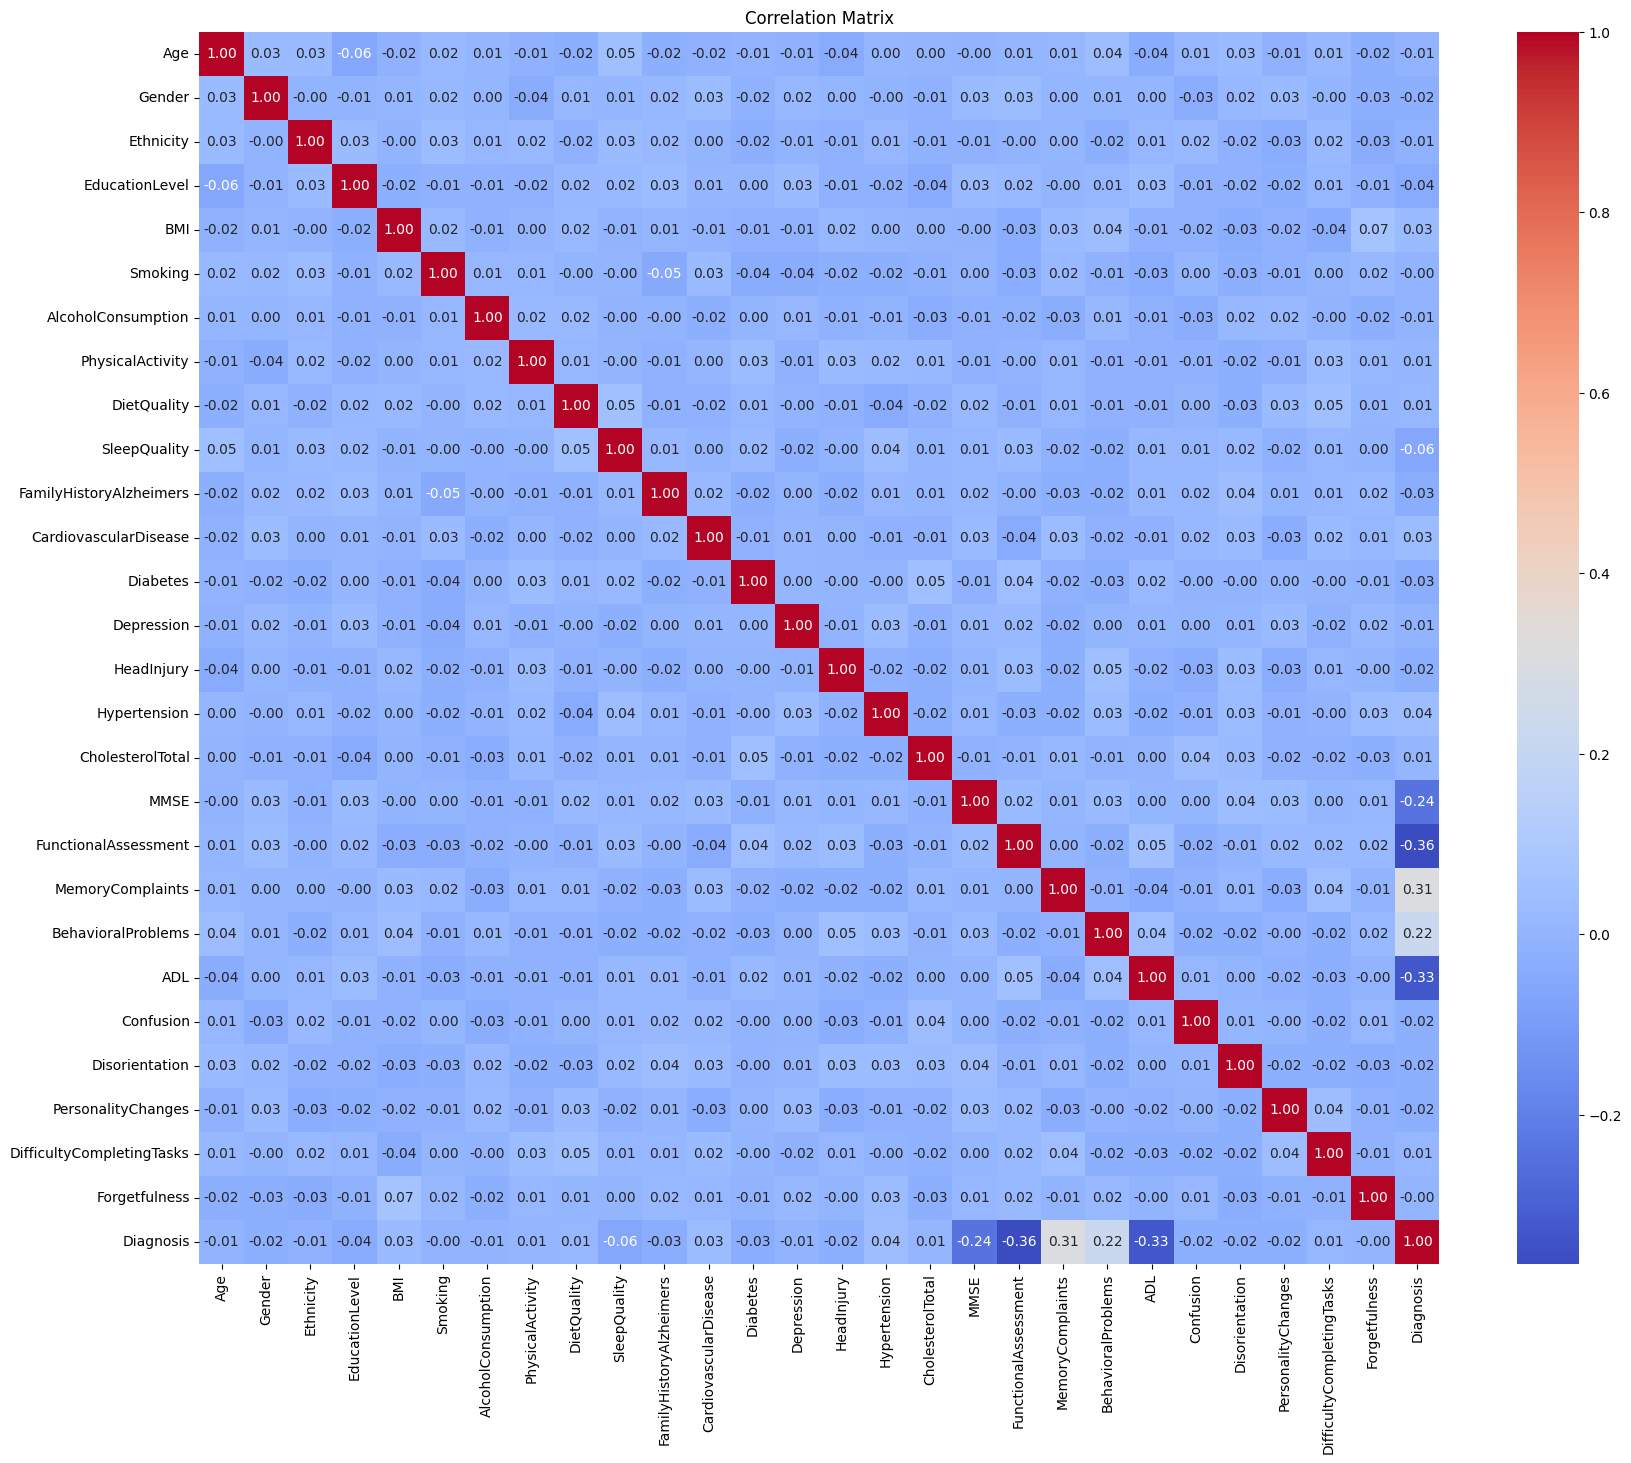

In [ ]:
# Creating a correlation matrix
corr_matrix = df.corr()
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

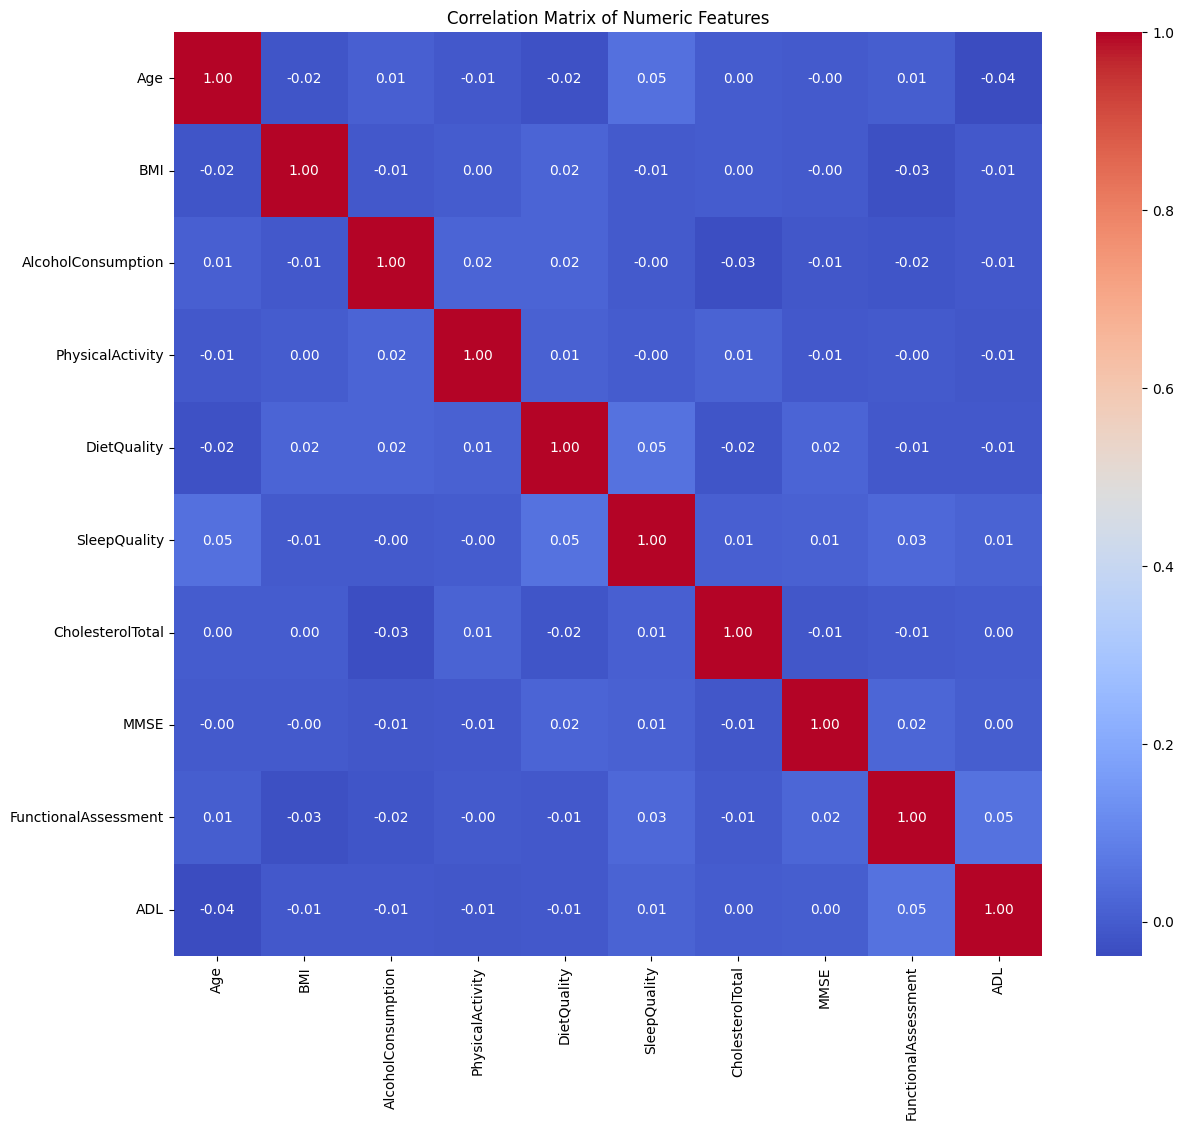

In [ ]:
# Creating a correlation matrix for numerical values only
# Compute correlation
corr_matrix = df[numerical_cols].corr()
plt.figure(figsize=(14,12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Numeric Features")
plt.show()

Nothing seems to have strong levels of correlation which means that there might be a lack of variance within the dataset which could cause issues within the modelling.

## Visualizing Feature Distributions

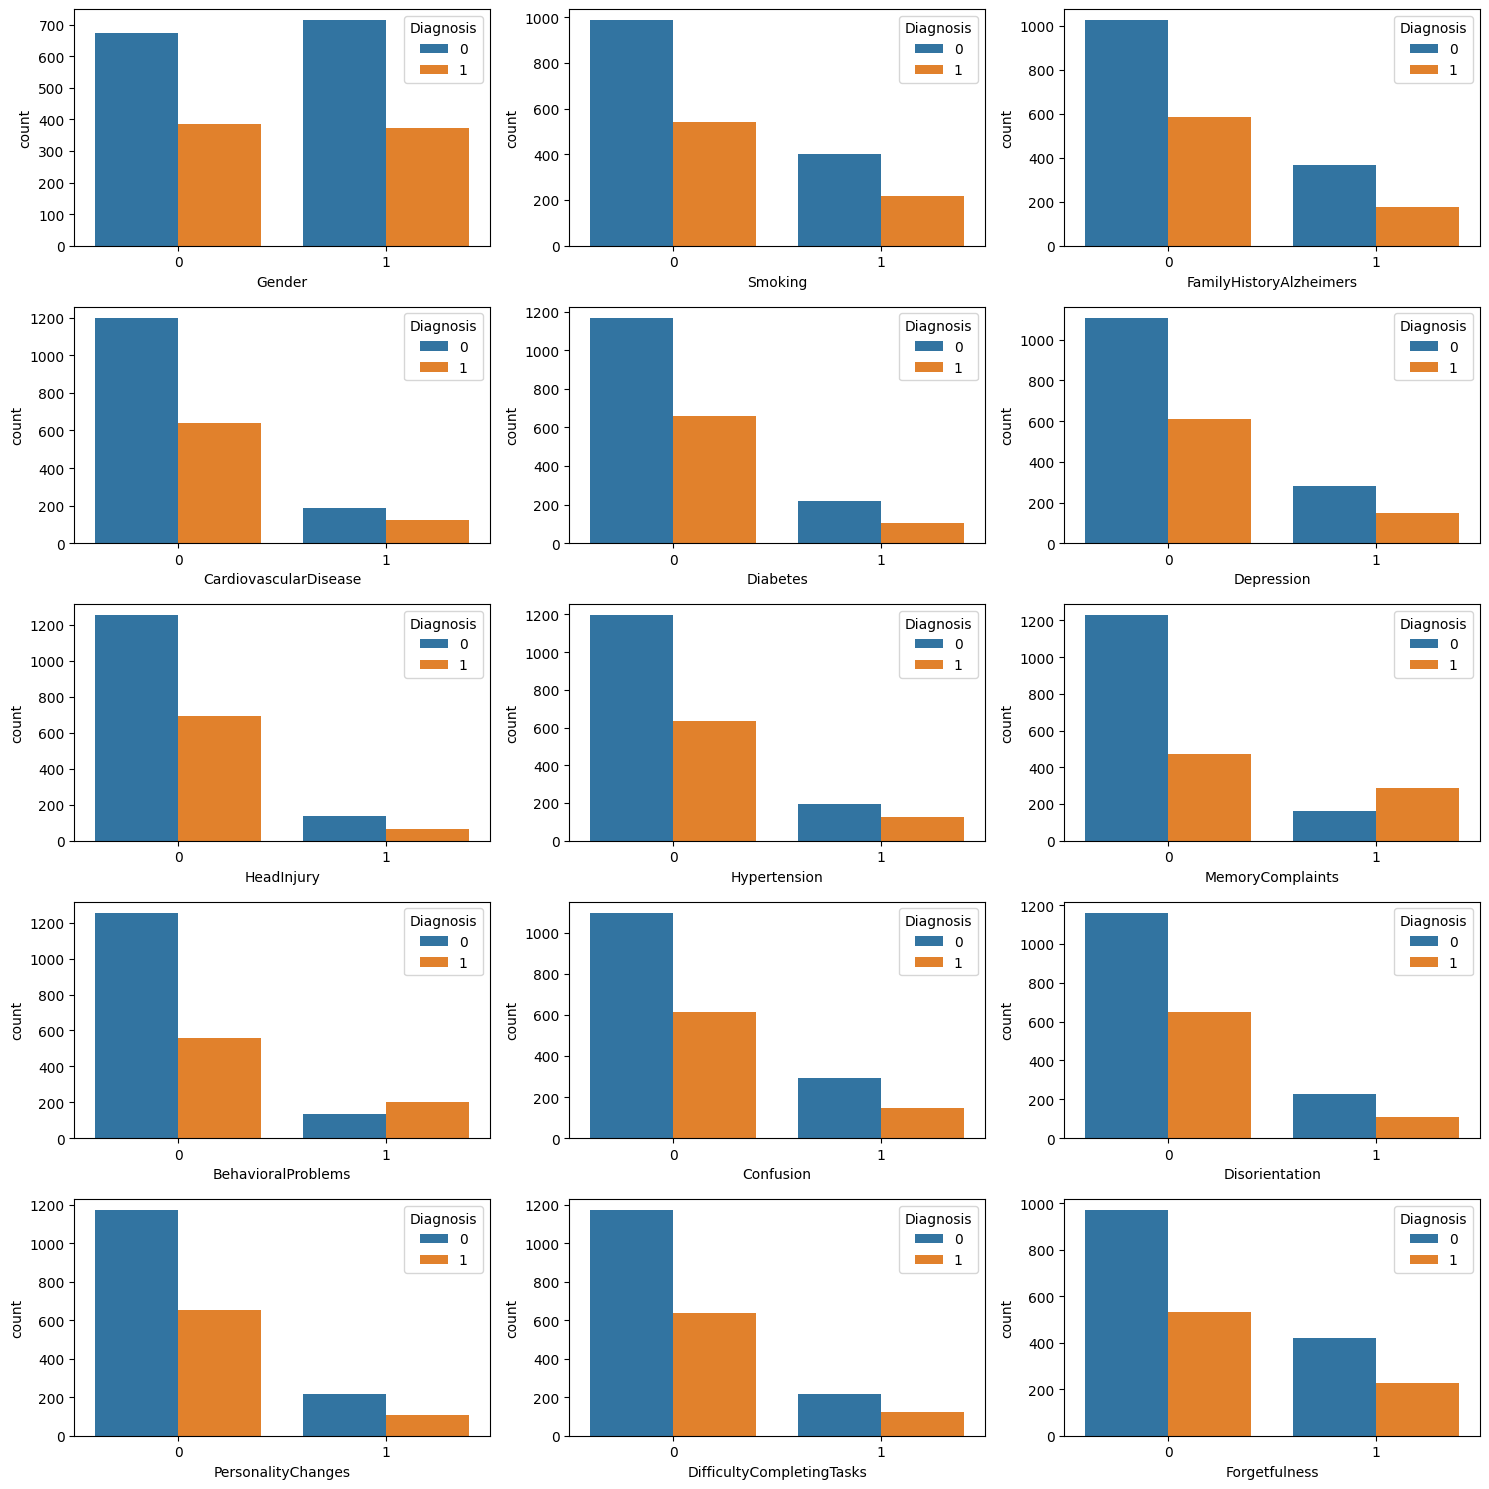

In [ ]:
# Visualizing how each binary feature relates to diagnosis
fig, axes = plt.subplots(5, 3, figsize=(15,15))
for i, col in enumerate(binary_cols):
    sns.countplot(x=col, hue='Diagnosis', data=df, ax=axes[i//3, i%3])
plt.tight_layout()
plt.show()

Within these visualizations we can see interesting patterns between the fact that gender has a fairly even distribution between male and female diagnosis. On the other hand MemoryComplaints has more people with a positive diagnosis in proportion to not. BehavioralProblems also has a higher proportion of people with a positive daignosis in the positive category.

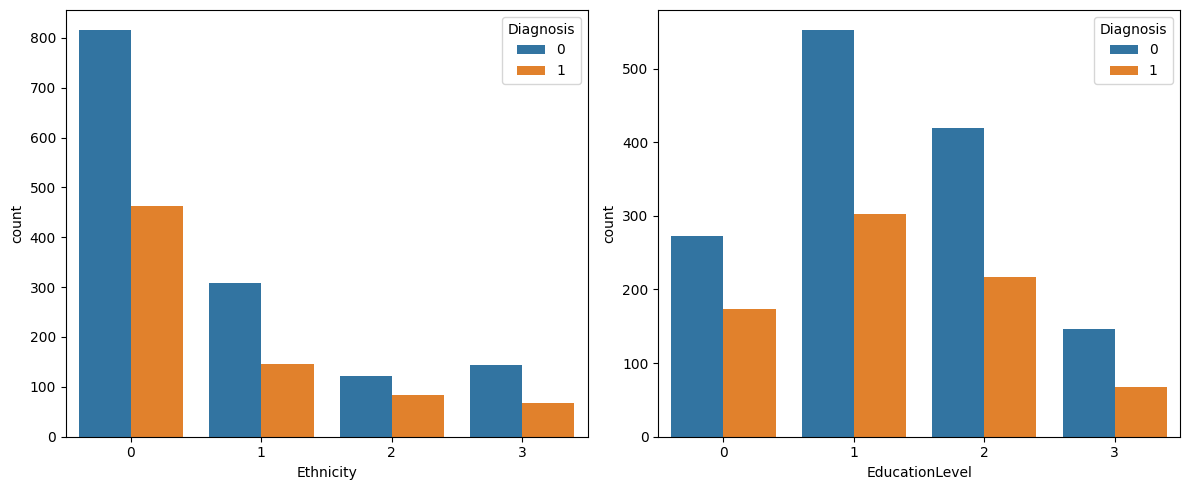

In [ ]:
# Visualizing categorical values compared to diagnosis
fig, axes = plt.subplots(1, 2, figsize=(12,5))
for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, hue='Diagnosis', data=df, ax=axes[i])
plt.tight_layout()
plt.show()

Within these distributions we can see that the ethnicity categories that are not white have a much smaller count in total which might be caused by sampling error or some bias within the dataset.

# Train Test Split

In [ ]:
# Computing a 80/20 Train/Test Split
# Random State = 42
X = df.drop("Diagnosis", axis=1)
y = df["Diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# PreProcessing Pipelines

In [ ]:
# normalizing the binary and categorical columns using Standard Scaler and OneHotEncoder functions
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols),
        ('bin', 'passthrough', binary_cols)
    ]
)

# Training Models

In [ ]:
# Storing results here in order to compare afterwards
results = []

In [ ]:
# Detailing each model type and parameters needed
models = [
    ("Naive Bayes", GaussianNB(), {}),
    ("KNN", KNeighborsClassifier(), {'n_neighbors':[3,5,7], 'weights':['uniform','distance']}),
    ("Decision Tree", DecisionTreeClassifier(random_state=42), {'max_depth':[None,5,10], 'min_samples_split':[2,5]}),
    ("Logistic Regression", LogisticRegression(max_iter=1000), {'C':[0.01,0.1,1,10]}),
    ("Random Forest", RandomForestClassifier(random_state=42), {'n_estimators':[50,100], 'max_depth':[None,5,10]}),
    ("SVM", SVC(), {'C':[0.1,1,10], 'kernel':['linear','rbf']}),
    ("Gradient Boosting", GradientBoostingClassifier(random_state=42), {'n_estimators':[50,100], 'learning_rate':[0.01,0.1]})
]



===== Training Naive Bayes =====


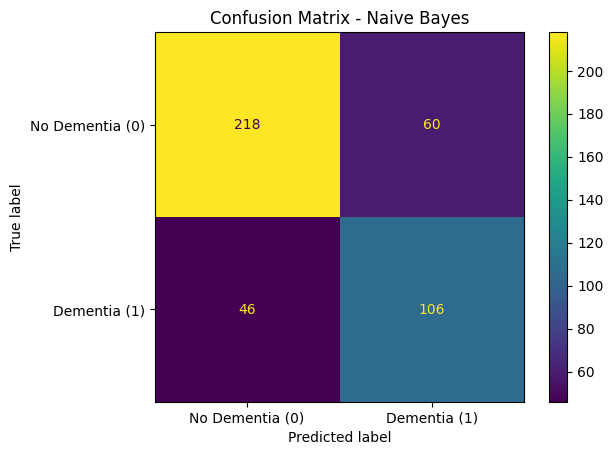

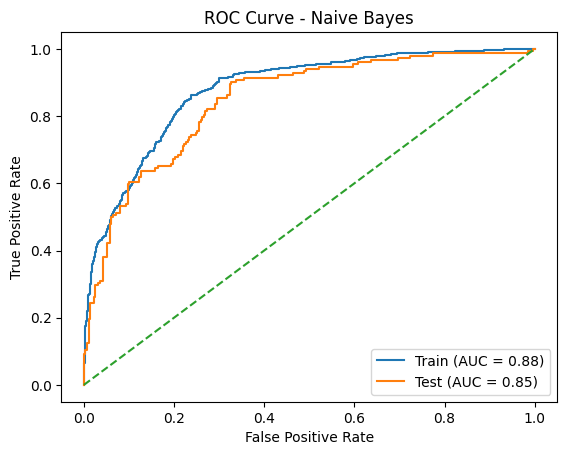

Best params: {}
Efficiency Score: 0.02

--- Train vs Test ---
Train Accuracy: 0.8
Test Accuracy: 0.75
Train Recall: 0.7
Test Recall: 0.7
Train AUC: 0.88
Test AUC: 0.85

--- Cross Validation ---
CV Accuracy: 0.79
CV Recall: 0.69

--- Timing ---
Training time (s): 0.66
Prediction time (s): 0.04

===== Training KNN =====


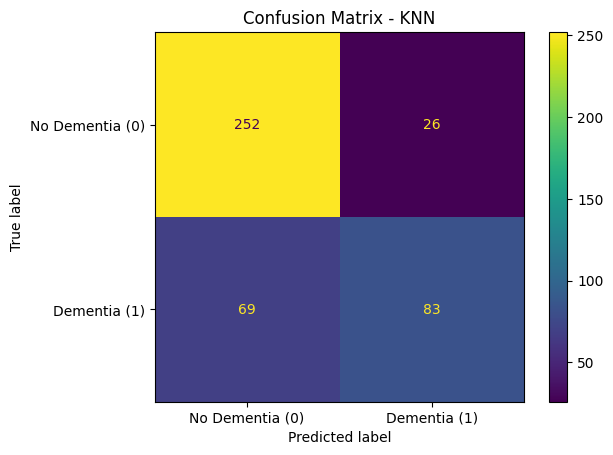

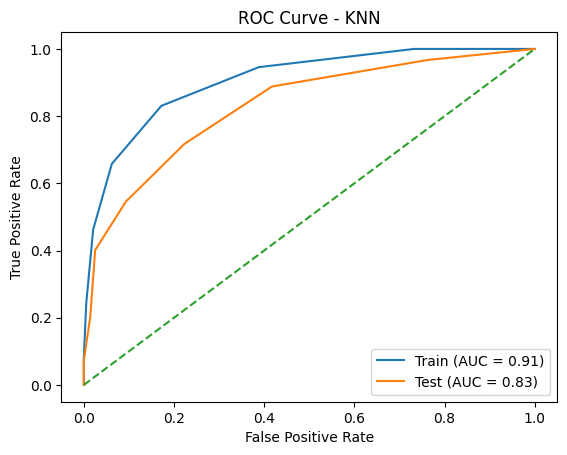

Best params: {'classifier__n_neighbors': 7, 'classifier__weights': 'uniform'}
Efficiency Score: 0.02

--- Train vs Test ---
Train Accuracy: 0.84
Test Accuracy: 0.78
Train Recall: 0.66
Test Recall: 0.55
Train AUC: 0.91
Test AUC: 0.83

--- Cross Validation ---
CV Accuracy: 0.77
CV Recall: 0.54

--- Timing ---
Training time (s): 1.73
Prediction time (s): 0.03

===== Training Decision Tree =====


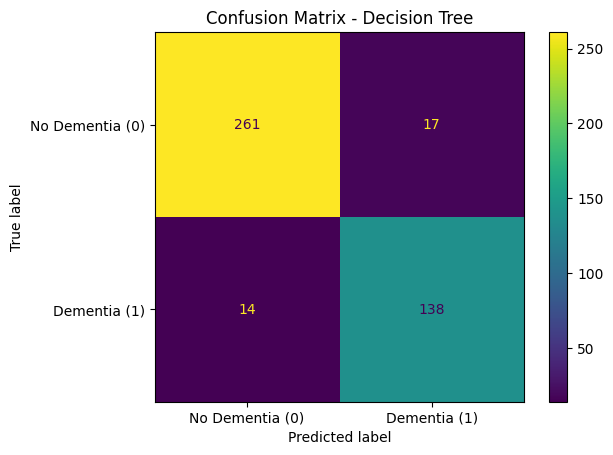

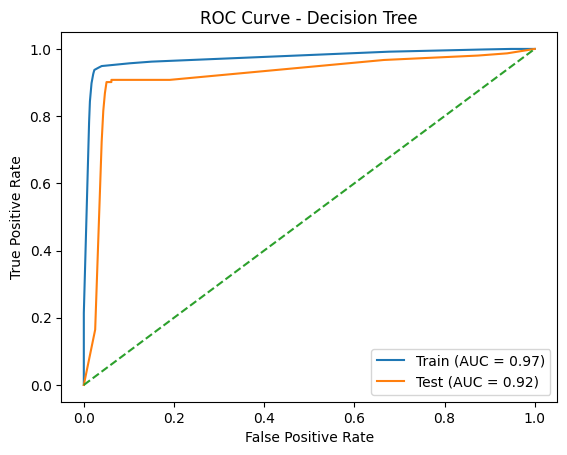

Best params: {'classifier__max_depth': 5, 'classifier__min_samples_split': 2}
Efficiency Score: 0.03

--- Train vs Test ---
Train Accuracy: 0.96
Test Accuracy: 0.93
Train Recall: 0.94
Test Recall: 0.91
Train AUC: 0.97
Test AUC: 0.92

--- Cross Validation ---
CV Accuracy: 0.94
CV Recall: 0.9

--- Timing ---
Training time (s): 2.44
Prediction time (s): 0.01

===== Training Logistic Regression =====


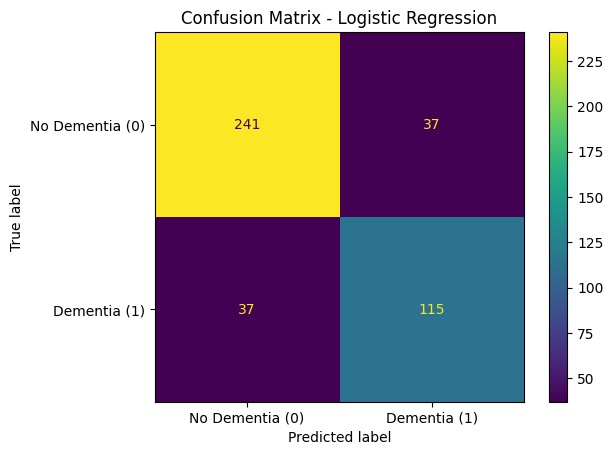

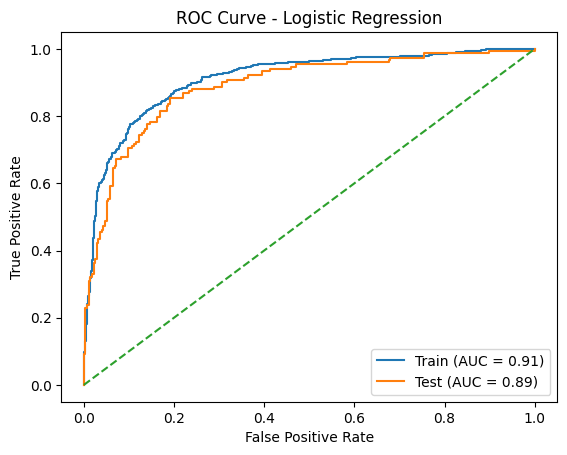

Best params: {'classifier__C': 1}
Efficiency Score: 0.03

--- Train vs Test ---
Train Accuracy: 0.85
Test Accuracy: 0.83
Train Recall: 0.75
Test Recall: 0.76
Train AUC: 0.91
Test AUC: 0.89

--- Cross Validation ---
CV Accuracy: 0.84
CV Recall: 0.73

--- Timing ---
Training time (s): 1.12
Prediction time (s): 0.02

===== Training Random Forest =====


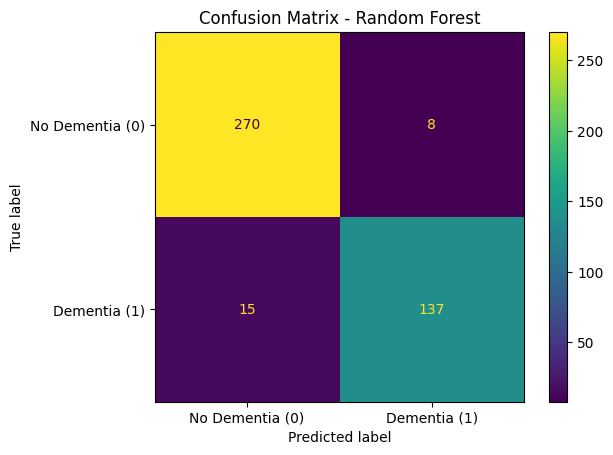

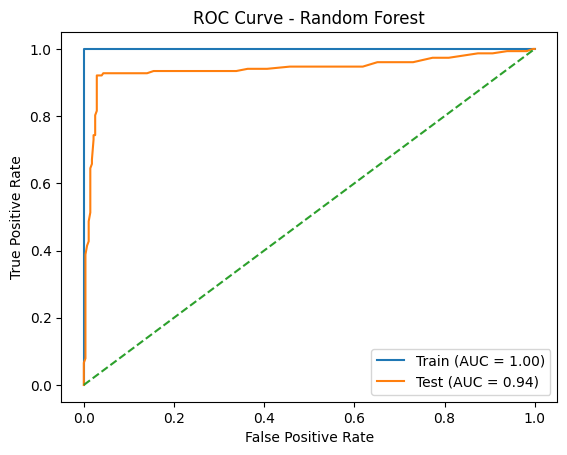

Best params: {'classifier__max_depth': None, 'classifier__n_estimators': 100}
Efficiency Score: 0.03

--- Train vs Test ---
Train Accuracy: 1.0
Test Accuracy: 0.95
Train Recall: 1.0
Test Recall: 0.9
Train AUC: 1.0
Test AUC: 0.94

--- Cross Validation ---
CV Accuracy: 0.94
CV Recall: 0.86

--- Timing ---
Training time (s): 16.22
Prediction time (s): 0.02

===== Training SVM =====


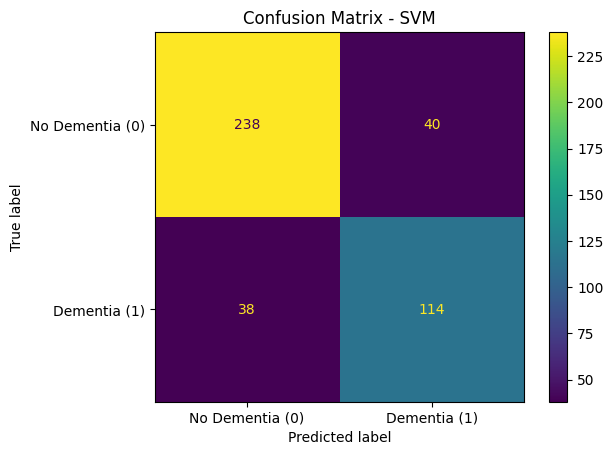

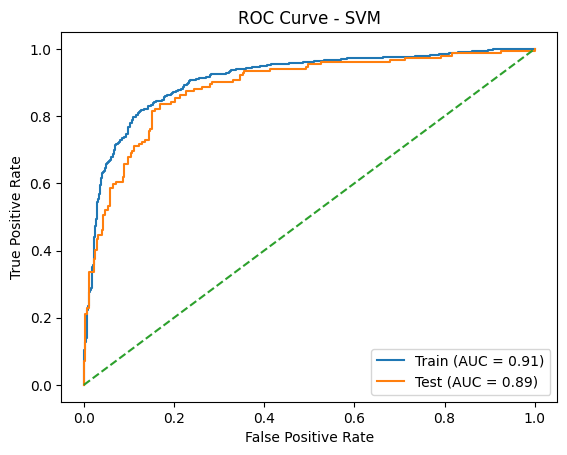

Best params: {'classifier__C': 1, 'classifier__kernel': 'linear'}
Efficiency Score: 0.03

--- Train vs Test ---
Train Accuracy: 0.85
Test Accuracy: 0.82
Train Recall: 0.75
Test Recall: 0.75
Train AUC: 0.91
Test AUC: 0.89

--- Cross Validation ---
CV Accuracy: 0.84
CV Recall: 0.73

--- Timing ---
Training time (s): 4.67
Prediction time (s): 0.03

===== Training Gradient Boosting =====


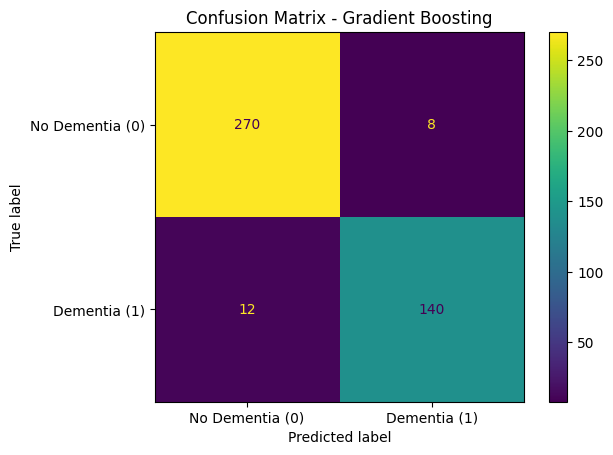

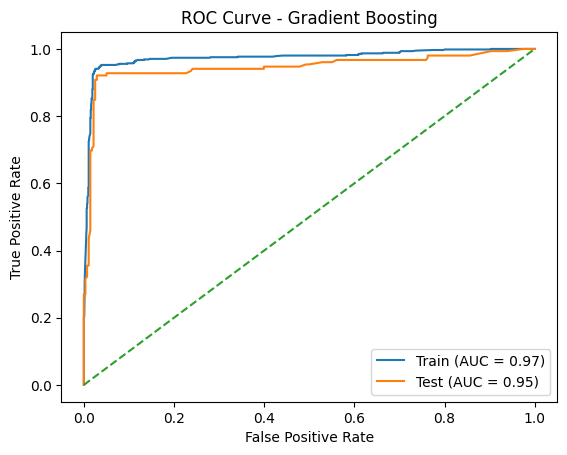

Best params: {'classifier__learning_rate': 0.1, 'classifier__n_estimators': 50}
Efficiency Score: 0.03

--- Train vs Test ---
Train Accuracy: 0.96
Test Accuracy: 0.95
Train Recall: 0.93
Test Recall: 0.92
Train AUC: 0.97
Test AUC: 0.95

--- Cross Validation ---
CV Accuracy: 0.95
CV Recall: 0.92

--- Timing ---
Training time (s): 11.0
Prediction time (s): 0.01


,Model,best_model,Train Accuracy,Test Accuracy,Train Recall,Test Recall,Train AUC,Test AUC,CV Accuracy,CV Recall,Efficiency Score
0,Gradient Boosting,"(ColumnTransformer(transformers=[('num', Stand...",0.96,0.95,0.93,0.92,0.97,0.95,0.95,0.92,0.03
1,Random Forest,"(ColumnTransformer(transformers=[('num', Stand...",1.00,0.95,1.00,0.90,1.00,0.94,0.94,0.86,0.03
2,Decision Tree,"(ColumnTransformer(transformers=[('num', Stand...",0.96,0.93,0.94,0.91,0.97,0.92,0.94,0.90,0.03
3,Logistic Regression,"(ColumnTransformer(transformers=[('num', Stand...",0.85,0.83,0.75,0.76,0.91,0.89,0.84,0.73,0.03
4,SVM,"(ColumnTransformer(transformers=[('num', Stand...",0.85,0.82,0.75,0.75,0.91,0.89,0.84,0.73,0.03
5,Naive Bayes,"(ColumnTransformer(transformers=[('num', Stand...",0.80,0.75,0.70,0.70,0.88,0.85,0.79,0.69,0.02
6,KNN,"(ColumnTransformer(transformers=[('num', Stand...",0.84,0.78,0.66,0.55,0.91,0.83,0.77,0.54,0.02



Top 5 features for Naive Bayes:
Confusion: 0.397
BehavioralProblems: 0.306
MemoryComplaints: 0.189
Disorientation: 0.187
Hypertension: 0.107

Top 5 features for KNN:
MemoryComplaints: 0.550
Disorientation: 0.465
Hypertension: 0.355
BehavioralProblems: 0.034
AlcoholConsumption: 0.015

Top 5 features for Decision Tree:
MMSE: 0.270
ADL: 0.226
FunctionalAssessment: 0.199
Forgetfulness: 0.160
Ethnicity: 0.116

Top 5 features for Logistic Regression:
Forgetfulness: 0.216
Ethnicity: 0.203
FunctionalAssessment: 0.105
ADL: 0.098
MMSE: 0.068

Top 5 features for Random Forest:
FunctionalAssessment: 0.193
ADL: 0.187
MMSE: 0.130
Forgetfulness: 0.091
Ethnicity: 0.051

Top 5 features for SVM:
Forgetfulness: 0.231
Ethnicity: 0.203
FunctionalAssessment: 0.105
ADL: 0.103
MMSE: 0.066

Top 5 features for Gradient Boosting:
FunctionalAssessment: 0.249
MMSE: 0.247
ADL: 0.241
Forgetfulness: 0.158
Ethnicity: 0.089

=== Overall Top 10 Contributing Factors Across All Models ===
FunctionalAssessment: 0.1195
For

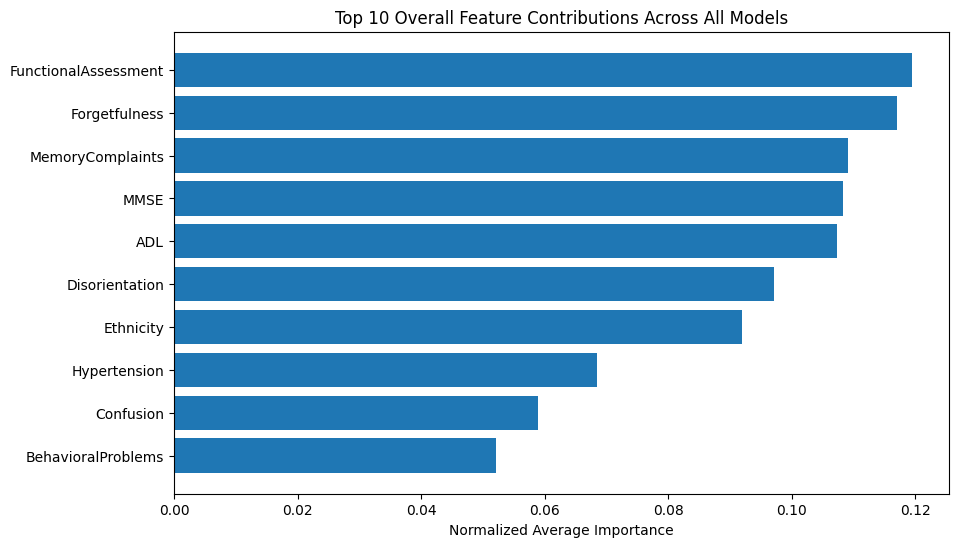

In [ ]:
results = []

# Loop over models
for i, (name, model, param_grid) in enumerate(models):
    print(f"\n===== Training {name} =====")

    # Pipeline
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Prefix params for GridSearch
    param_grid_prefixed = {f"classifier__{k}": v for k, v in param_grid.items()}

    grid = GridSearchCV(pipe, param_grid=param_grid_prefixed, cv=5, scoring='accuracy', n_jobs=-1)

    # ========================
    # TRAIN MODEL
    # ========================
    start_train = time.time()
    grid.fit(X_train, y_train)
    end_train = time.time()

    best_model = grid.best_estimator_

    # ========================
    # TRAIN PREDICTIONS
    # ========================
    y_train_pred = best_model.predict(X_train)
    try:
        y_train_prob = best_model.predict_proba(X_train)[:,1]
    except:
        y_train_prob = best_model.decision_function(X_train)

    train_acc = accuracy_score(y_train, y_train_pred)
    train_rec = recall_score(y_train, y_train_pred)
    fpr_train, tpr_train, _ = roc_curve(y_train, y_train_prob)
    auc_train = auc(fpr_train, tpr_train)

    # ========================
    # TEST PREDICTIONS
    # ========================
    start_pred = time.time()
    y_pred = best_model.predict(X_test)
    end_pred = time.time()

    try:
        y_test_prob = best_model.predict_proba(X_test)[:,1]
    except:
        y_test_prob = best_model.decision_function(X_test)

    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob)
    auc_test = auc(fpr_test, tpr_test)

    # ========================
    # CROSS VALIDATION
    # ========================
    cv_accuracy = cross_val_score(best_model, X_train, y_train, cv=5, scoring='accuracy').mean()
    cv_recall = cross_val_score(best_model, X_train, y_train, cv=5, scoring='recall').mean()

    # ========================
    # CONFUSION MATRIX
    # ========================
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=["No Dementia (0)", "Dementia (1)"])
    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    # ========================
    # ROC CURVE (TRAIN vs TEST)
    # ========================
    plt.figure()
    plt.plot(fpr_train, tpr_train, label=f'Train (AUC = {auc_train:.2f})')
    plt.plot(fpr_test, tpr_test, label=f'Test (AUC = {auc_test:.2f})')
    plt.plot([0,1], [0,1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend()
    plt.show()

    # ========================
    # EFFICIENCY
    # ========================
    efficiency_score = (cv_accuracy ** 2) / X_train.shape[1]

    # ========================
    # PRINT RESULTS
    # ========================
    print("Best params:", grid.best_params_)
    print("Efficiency Score:", round(efficiency_score, 2))
    print("\n--- Train vs Test ---")
    print("Train Accuracy:", round(train_acc, 2))
    print("Test Accuracy:", round(acc, 2))
    print("Train Recall:", round(train_rec, 2))
    print("Test Recall:", round(rec, 2))
    print("Train AUC:", round(auc_train, 2))
    print("Test AUC:", round(auc_test, 2))
    print("\n--- Cross Validation ---")
    print("CV Accuracy:", round(cv_accuracy, 2))
    print("CV Recall:", round(cv_recall, 2))
    print("\n--- Timing ---")
    print("Training time (s):", round(end_train - start_train, 2))
    print("Prediction time (s):", round(end_pred - start_pred, 2))

    # ========================
    # STORE RESULTS (including model object)
    # ========================
    results.append({
        "Model": name,
        "best_model": best_model,
        "Train Accuracy": round(train_acc, 2),
        "Test Accuracy": round(acc, 2),
        "Train Recall": round(train_rec, 2),
        "Test Recall": round(rec, 2),
        "Train AUC": round(auc_train, 2),
        "Test AUC": round(auc_test, 2),
        "CV Accuracy": round(cv_accuracy, 2),
        "CV Recall": round(cv_recall, 2),
        "Efficiency Score": round(efficiency_score, 2)
    })

# ========================
# CREATE RESULTS TABLE
# ========================
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Test AUC", ascending=False).reset_index(drop=True)
display(results_df)

# ========================
# FEATURE IMPORTANCE PER MODEL & OVERALL
# ========================
from collections import defaultdict

overall_importances = defaultdict(list)

for res in results:
    best_model = res['best_model']
    try:
        # Get feature names from preprocessor
        try:
            onehot_features = best_model.named_steps['preprocessor'].transformers_[0][1].get_feature_names_out(categorical_cols)
            all_features = np.concatenate([onehot_features, numerical_cols])
        except:
            all_features = numerical_cols + binary_cols + categorical_cols

        clf = best_model.named_steps['classifier']

        if hasattr(clf, 'feature_importances_'):
            importances = clf.feature_importances_
        elif hasattr(clf, 'coef_'):
            importances = np.abs(clf.coef_[0])
        else:
            perm = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
            importances = perm.importances_mean

        importances = importances / importances.sum()  # normalize
        for f, imp in zip(all_features, importances):
            overall_importances[f].append(imp)

        # Show per-model top 5 features
        top_features = sorted(zip(all_features, importances), key=lambda x: x[1], reverse=True)[:5]
        print(f"\nTop 5 features for {res['Model']}:")
        for f, imp in top_features:
            print(f"{f}: {imp:.3f}")

    except Exception as e:
        print(f"Could not extract feature importance for {res['Model']}: {e}")

# Overall feature contribution
avg_importances = {f: np.mean(imps) for f, imps in overall_importances.items()}
sorted_features = sorted(avg_importances.items(), key=lambda x: x[1], reverse=True)

print("\n=== Overall Top 10 Contributing Factors Across All Models ===")
for f, imp in sorted_features[:10]:
    print(f"{f}: {imp:.4f}")

plt.figure(figsize=(10,6))
plt.barh([f for f,_ in sorted_features[:10]][::-1],
         [imp for _,imp in sorted_features[:10]][::-1])
plt.xlabel("Normalized Average Importance")
plt.title("Top 10 Overall Feature Contributions Across All Models")
plt.show()

In [ ]:
best_model = results_df.iloc[0]

print("===== BEST MODEL =====")
print("Model:", best_model["Model"])
print("Test AUC:", best_model["Test AUC"])
print("Test Accuracy:", best_model["Test Accuracy"])
print("Test Recall:", best_model["Test Recall"])

===== BEST MODEL =====
Model: Gradient Boosting
Test AUC: 0.95
Test Accuracy: 0.95
Test Recall: 0.92


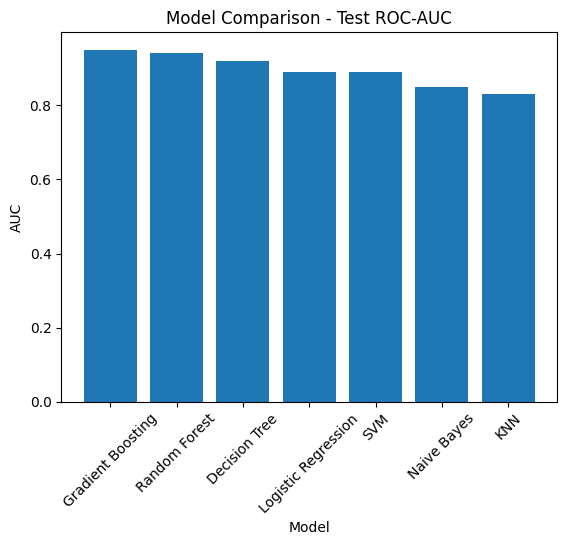

In [ ]:
plt.figure()
plt.bar(results_df["Model"], results_df["Test AUC"])
plt.xticks(rotation=45)
plt.title("Model Comparison - Test ROC-AUC")
plt.xlabel("Model")
plt.ylabel("AUC")
plt.show()

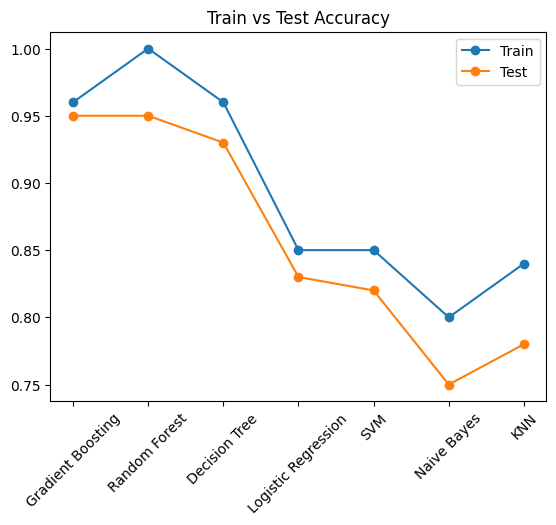

In [ ]:
plt.figure()
plt.plot(results_df["Model"], results_df["Train Accuracy"], marker='o', label="Train")
plt.plot(results_df["Model"], results_df["Test Accuracy"], marker='o', label="Test")
plt.xticks(rotation=45)
plt.legend()
plt.title("Train vs Test Accuracy")
plt.show()

# Going a Step Further - Implementing a Neural Network

In [ ]:
#Defining the Model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_processed.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # binary classification
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#Compiling the Model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
#Training the Model
history = model.fit(
    X_train_processed, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.6487 - loss: 0.6388 - val_accuracy: 0.7558 - val_loss: 0.5408
Epoch 2/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7273 - loss: 0.5432 - val_accuracy: 0.7791 - val_loss: 0.4791
Epoch 3/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7716 - loss: 0.4843 - val_accuracy: 0.8140 - val_loss: 0.4348
Epoch 4/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8087 - loss: 0.4469 - val_accuracy: 0.8343 - val_loss: 0.4101
Epoch 5/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7935 - loss: 0.4377 - val_accuracy: 0.8285 - val_loss: 0.3969
Epoch 6/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8160 - loss: 0.4107 - val_accuracy: 0.8372 - val_loss: 0.3817
Epoch 7/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8335 - loss: 0.3948 - val_accuracy: 0.8401 - val_loss: 0.3729
Epoch 8/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8204 - loss: 0.4039 - val_accuracy: 0.8488 - val_los

In [ ]:
#Evaluating the Models Predictions
y_prob = model.predict(X_test_processed)
y_pred = (y_prob > 0.5).astype(int)

from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Accuracy: 0.858139534883721
ROC-AUC: 0.9103085952290799
              precision    recall  f1-score   support

           0       0.89      0.88      0.89       278
           1       0.79      0.81      0.80       152

    accuracy                           0.86       430
   macro avg       0.84      0.85      0.85       430
weighted avg       0.86      0.86      0.86       430



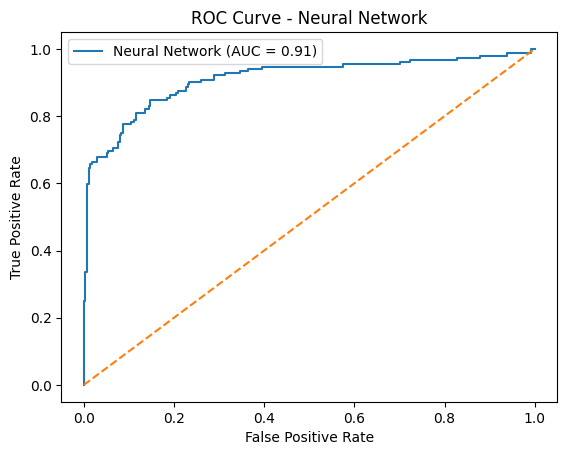

In [ ]:
# Visualizing the Neural Network ROC Curve
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_prob)
auc_nn = auc(fpr_nn, tpr_nn)

plt.figure()
plt.plot(fpr_nn, tpr_nn, label=f'Neural Network (AUC = {auc_nn:.2f})')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Neural Network")
plt.legend()
plt.show()